In [4]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
# prompt: load the planets dataset through seaborn

planets = sns.load_dataset('planets')


In [6]:
planets.head(10)

,method,number,orbital_period,mass,distance,year
0,Radial Velocity,1,269.300,7.10,77.40,2006
1,Radial Velocity,1,874.774,2.21,56.95,2008
2,Radial Velocity,1,763.000,2.60,19.84,2011
3,Radial Velocity,1,326.030,19.40,110.62,2007
4,Radial Velocity,1,516.220,10.50,119.47,2009
5,Radial Velocity,1,185.840,4.80,76.39,2008
6,Radial Velocity,1,1773.400,4.64,18.15,2002
7,Radial Velocity,1,798.500,NaN,21.41,1996
8,Radial Velocity,1,993.300,10.30,73.10,2008
9,Radial Velocity,2,452.800,1.99,74.79,2010


# Task

1. Dataframe exploration: shape, missing values, data types
2. Univariate (histograms and boxplots)
3. Based on histograms, fix missing values
4. Bivariate (correlation matrix)
5. In text, explain the 3 most correlated variable pairs
6. Hypothesis: 3 variables - 1 multivariate chart.
7. Reject/Fail to reject the hypothesis
8. In between, clean up the data - delete outliers/scale
9. Do you need to scale the data? If you did, standardize or normalize

In [7]:
planets.describe()

,number,orbital_period,mass,distance,year
count,1035.000000,992.000000,513.000000,808.000000,1035.000000
mean,1.785507,2002.917596,2.638161,264.069282,2009.070531
std,1.240976,26014.728304,3.818617,733.116493,3.972567
min,1.000000,0.090706,0.003600,1.350000,1989.000000
25%,1.000000,5.442540,0.229000,32.560000,2007.000000
50%,1.000000,39.979500,1.260000,55.250000,2010.000000
75%,2.000000,526.005000,3.040000,178.500000,2012.000000
max,7.000000,730000.000000,25.000000,8500.000000,2014.000000


In [8]:
planets.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1035 entries, 0 to 1034
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   method          1035 non-null   object 
 1   number          1035 non-null   int64  
 2   orbital_period  992 non-null    float64
 3   mass            513 non-null    float64
 4   distance        808 non-null    float64
 5   year            1035 non-null   int64  
dtypes: float64(3), int64(2), object(1)
memory usage: 48.6+ KB


In [9]:
# prompt: give me data types for each variable

planets.dtypes


,0
method,object
number,int64
orbital_period,float64
mass,float64
distance,float64
year,int64


In [10]:
planets.shape

(1035, 6)

In [11]:
# prompt: convert method to category

planets['method'] = planets['method'].astype('category')
planets.dtypes

,0
method,category
number,int64
orbital_period,float64
mass,float64
distance,float64
year,int64


In [12]:
planets.isna().sum()

,0
method,0
number,0
orbital_period,43
mass,522
distance,227
year,0


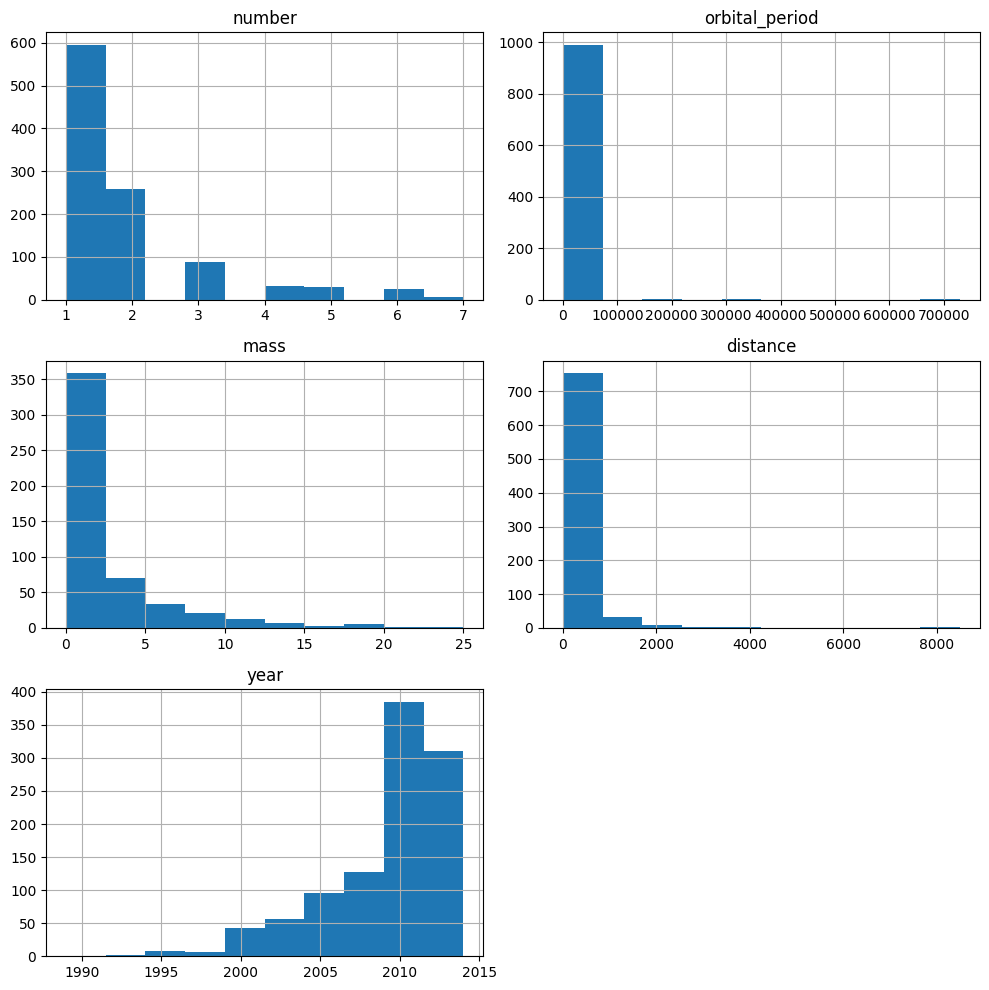

In [13]:
# prompt: provide histograms of each column

planets.hist(figsize=(10, 10))
plt.tight_layout()
plt.show()

In [14]:
# prompt: calculate mode of each column

print("Mode of each column:")
for col in planets.columns:
    # Handle categorical columns separately if needed, but mode works on any type
    # For numerical columns, this directly calculates the mode
    mode_val = planets[col].mode()
    print(f"{col}: {mode_val.tolist()}") # .tolist() to display all modes if multiple

Mode of each column:
method: ['Radial Velocity']
number: [1]
orbital_period: [123.0, 428.5, 883.0, 1845.0]
mass: [1.8, 1.9]
distance: [780.0]
year: [2011]


In [15]:
# prompt: for the column which have missing values, impute their missing values with their respective mode in a new dataframe planets_copy

planets_copy = planets.copy()

for col in planets_copy.columns:
    if planets_copy[col].isnull().any(): # Check if column has any missing values
        # Calculate the mode, handle cases where mode() returns multiple values
        mode_val = planets_copy[col].mode()[0]
        planets_copy[col].fillna(mode_val, inplace=True)

# Verify that missing values have been imputed in the new dataframe
print("Missing values in planets_copy after imputation:")
print(planets_copy.isna().sum())

Missing values in planets_copy after imputation:
method            0
number            0
orbital_period    0
mass              0
distance          0
year              0
dtype: int64


<ipython-input-15-9ea1113cc6c9>:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  planets_copy[col].fillna(mode_val, inplace=True)


In [16]:
planets_copy.describe()

,number,orbital_period,mass,distance,year
count,1035.000000,1035.000000,1035.000000,1035.000000,1035.000000
mean,1.785507,1924.814739,2.215436,377.225101,2009.070531
std,1.240976,25470.824631,2.719594,681.974000,3.972567
min,1.000000,0.090706,0.003600,1.350000,1989.000000
25%,1.000000,5.747860,1.285000,38.010000,2007.000000
50%,1.000000,49.532000,1.800000,105.490000,2010.000000
75%,2.000000,487.100000,1.800000,780.000000,2012.000000
max,7.000000,730000.000000,25.000000,8500.000000,2014.000000


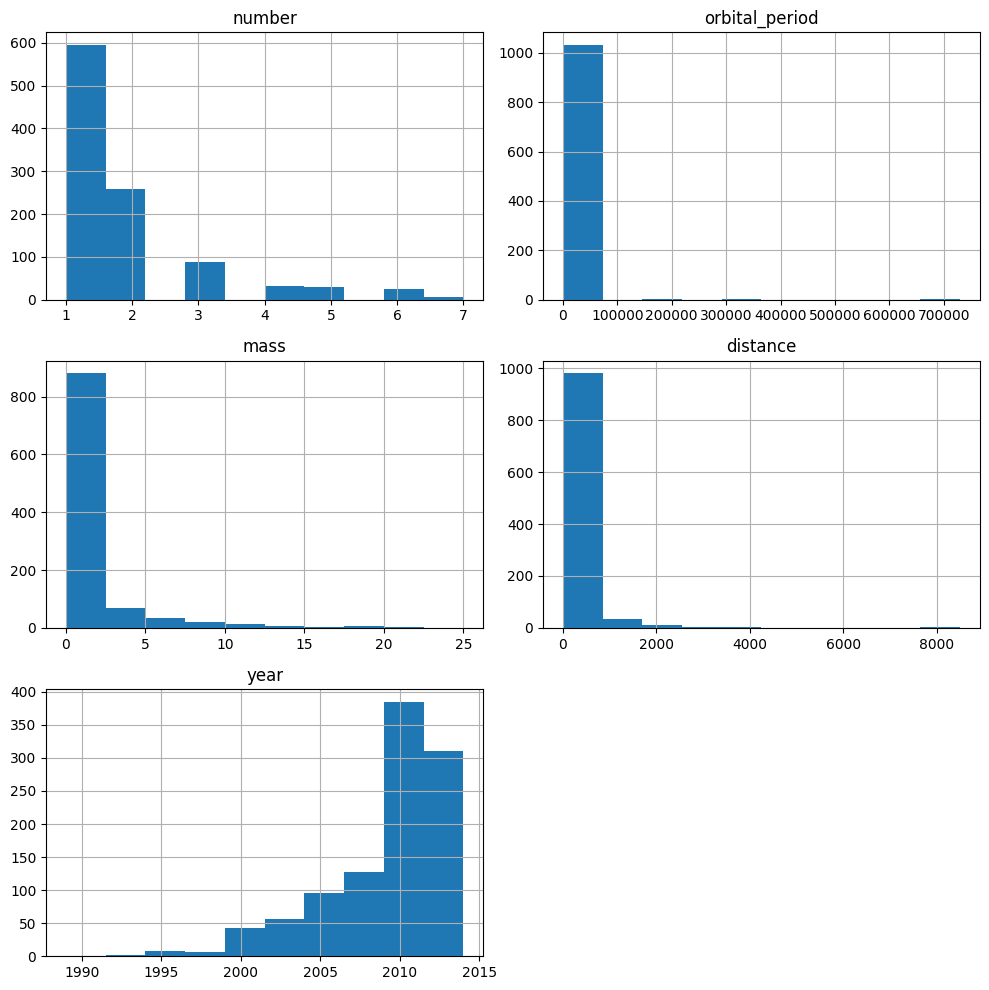

In [17]:
# prompt: now give me histograms of all columns in planets_copy

planets_copy.hist(figsize=(10, 10))
plt.tight_layout()
plt.show()

Correlation Matrix for Original Planets Dataset:
                  number  orbital_period      mass  distance      year
number          1.000000       -0.012570 -0.241429 -0.033638  0.147849
orbital_period -0.012570        1.000000  0.173725 -0.034365 -0.032333
mass           -0.241429        0.173725  1.000000  0.274082 -0.123787
distance       -0.033638       -0.034365  0.274082  1.000000  0.178922
year            0.147849       -0.032333 -0.123787  0.178922  1.000000

Correlation Matrix for Imputed Planets Dataset:
                  number  orbital_period      mass  distance      year
number          1.000000       -0.010748 -0.165879 -0.004139  0.147849
orbital_period -0.010748        1.000000  0.000736 -0.000963 -0.032582
mass           -0.165879        0.000736  1.000000 -0.031741 -0.152295
distance       -0.004139       -0.000963 -0.031741  1.000000  0.240712
year            0.147849       -0.032582 -0.152295  0.240712  1.000000


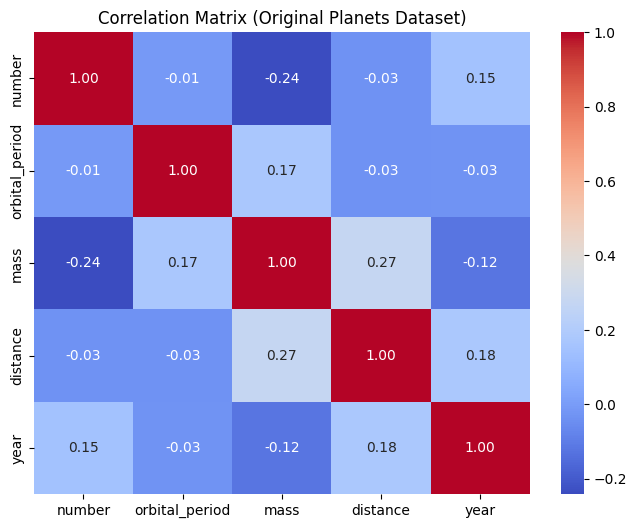

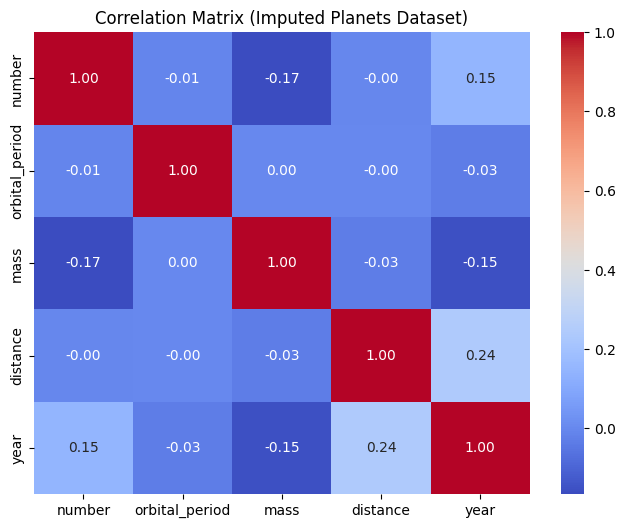

In [18]:
# prompt: give me correlation matrix of planets (original dataset) and planets_copy

# Select only the numerical columns for correlation matrix
planets_numerical = planets.select_dtypes(include=np.number)
planets_copy_numerical = planets_copy.select_dtypes(include=np.number)

# Calculate the correlation matrix for the original dataframe (handling NaNs)
correlation_matrix_original = planets_numerical.corr()

# Calculate the correlation matrix for the copy dataframe (after imputation)
correlation_matrix_copy = planets_copy_numerical.corr()

print("Correlation Matrix for Original Planets Dataset:")
print(correlation_matrix_original)

print("\nCorrelation Matrix for Imputed Planets Dataset:")
print(correlation_matrix_copy)

# Optionally visualize the correlation matrices
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix_original, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix (Original Planets Dataset)')
plt.show()

plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix_copy, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix (Imputed Planets Dataset)')
plt.show()

- The three most correlation variables according to imputed planets dataset are-
- mass and number (-0.17), year and mass (-0.15), and year and orbital_period (-0.03).


Hypothesis: the orbital period increases as the mass increases in different years

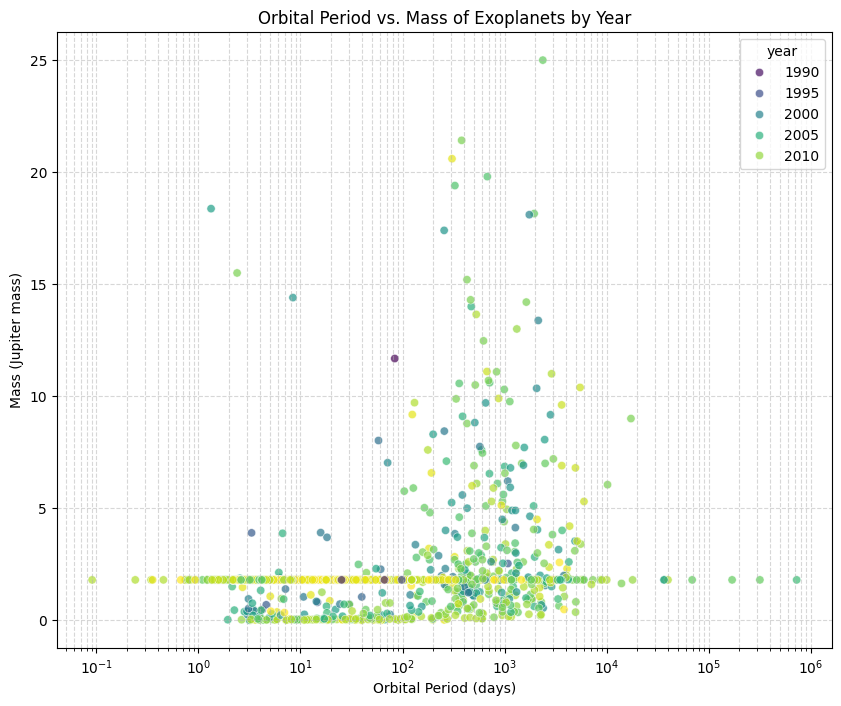

In [19]:
# prompt: generate a scatterplot of orbital period on x axis, mass on y-axis, and years in colors. use planets_copy

plt.figure(figsize=(10, 8))
sns.scatterplot(data=planets_copy, x='orbital_period', y='mass', hue='year', palette='viridis', alpha=0.7)
plt.xscale('log') # Often orbital periods are better viewed on a log scale
plt.xlabel('Orbital Period (days)')
plt.ylabel('Mass (Jupiter mass)')
plt.title('Orbital Period vs. Mass of Exoplanets by Year')
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.show()

In [20]:
# prompt: based on this scatterplot, my Hypothesis: the orbital period increases as the mass increases in different years (is it accepted or rejected)

# Reject the Hypothesis: the orbital period increases as the mass increases in different years.

# Explanation:
# Looking at the scatterplot, there is no clear visual trend where the orbital period consistently increases as the mass increases across different years.
# The data points are scattered across a wide range, and while there might be clusters or specific relationships within certain years, there isn't a uniform positive correlation (increasing orbital period with increasing mass) that holds true across all years represented by the different colors.
# The scatterplot shows a high degree of variability and no strong positive linear relationship between orbital period and mass, especially when considering the influence of the 'year' variable as represented by the color.
# Therefore, the visual evidence from the scatterplot does not support the hypothesis.

- Thus, hypothesis rejected

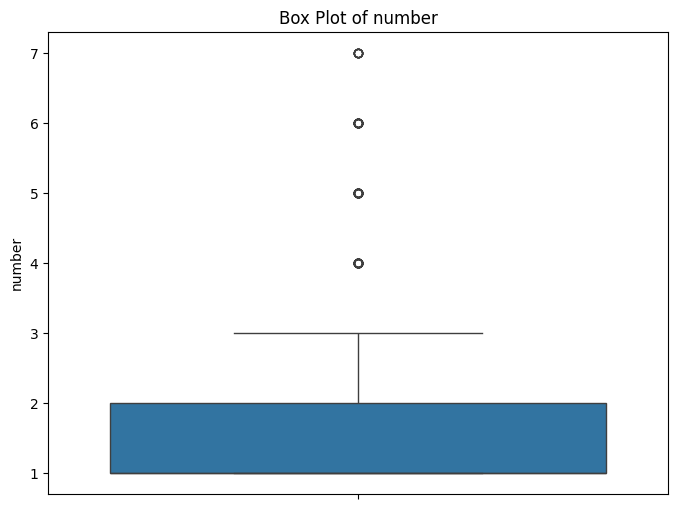

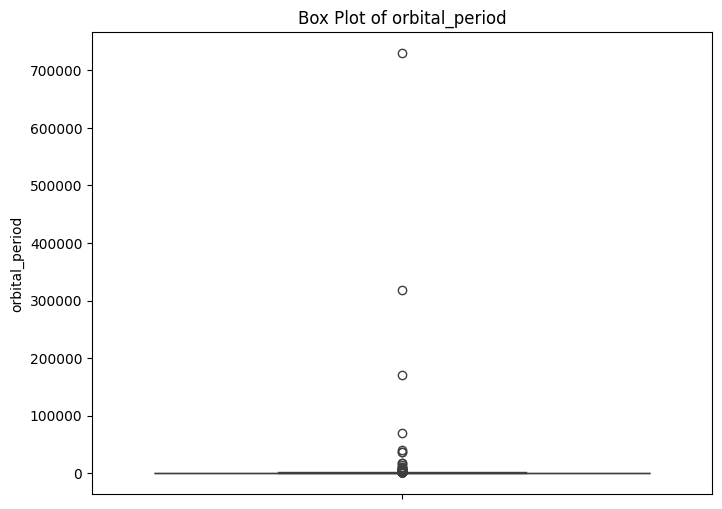

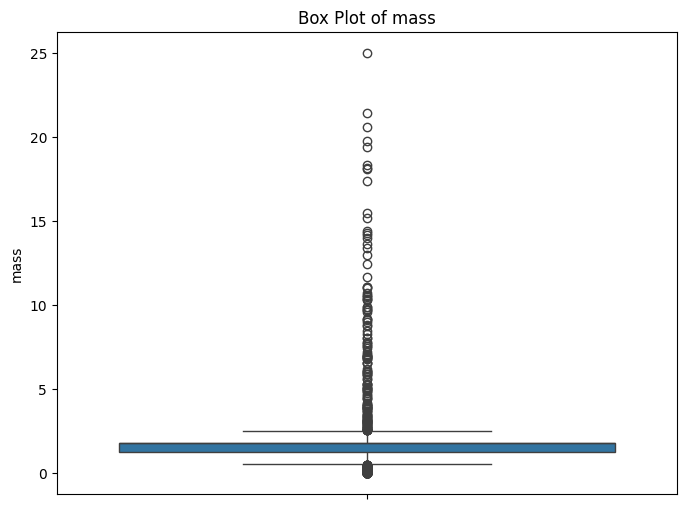

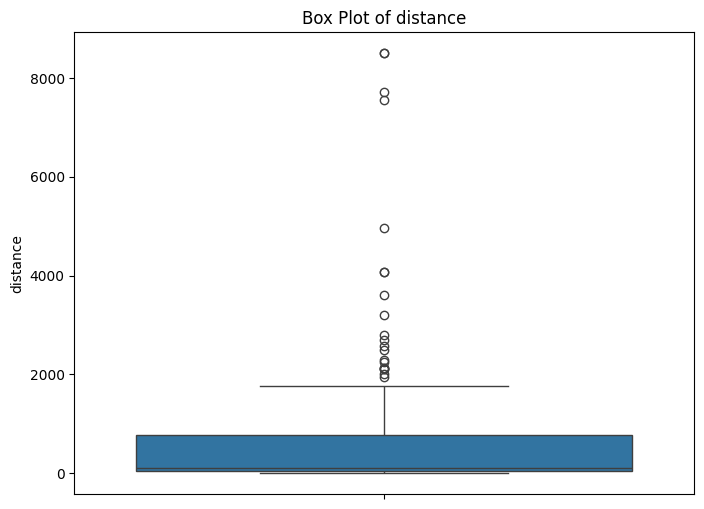

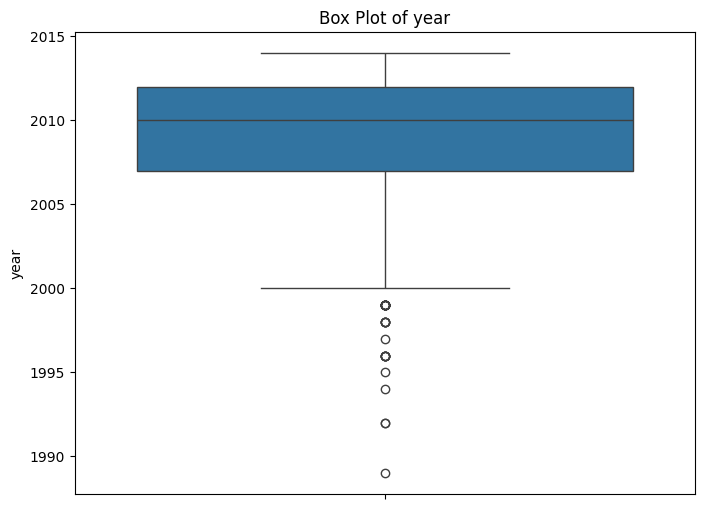

In [21]:
# prompt: give box plots of each column in planets_copy

# Select only numerical columns for box plots
planets_numerical = planets_copy.select_dtypes(include=np.number)

# Create box plots for each numerical column
for col in planets_numerical.columns:
    plt.figure(figsize=(8, 6))
    sns.boxplot(y=planets_numerical[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel(col)
    plt.show()

Shape of planets_copy after outlier removal: (857, 6)


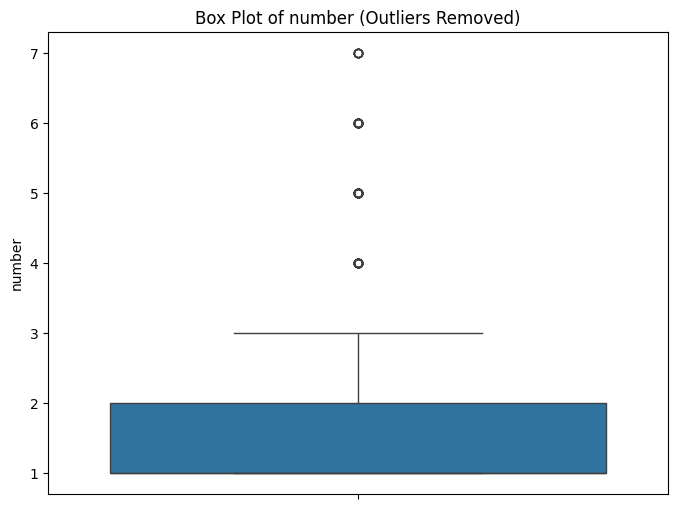

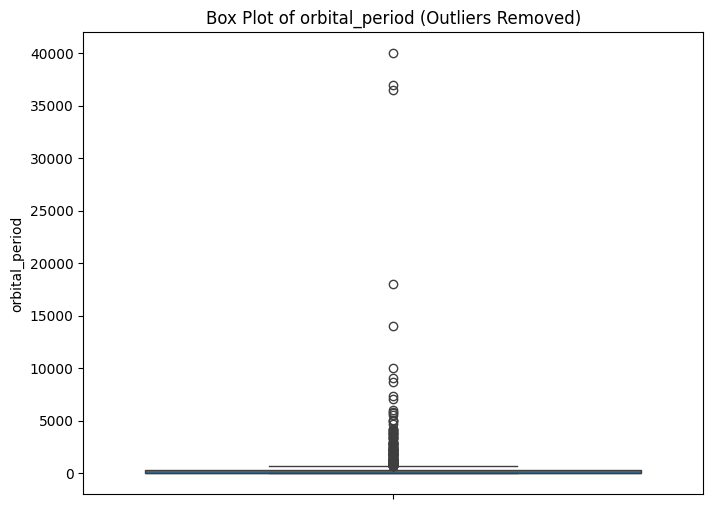

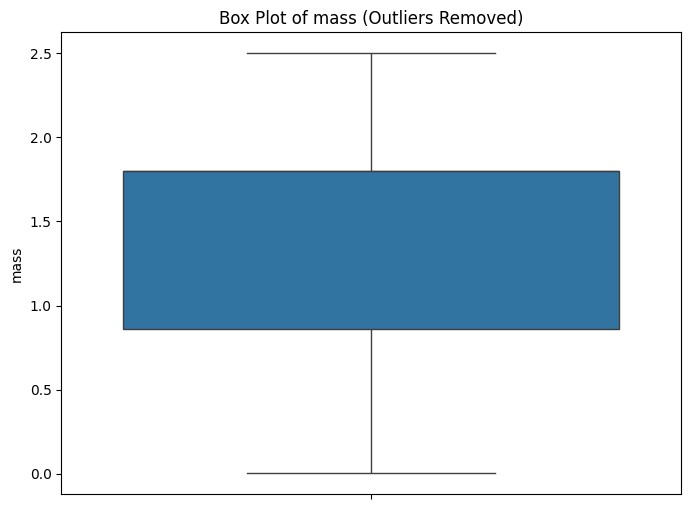

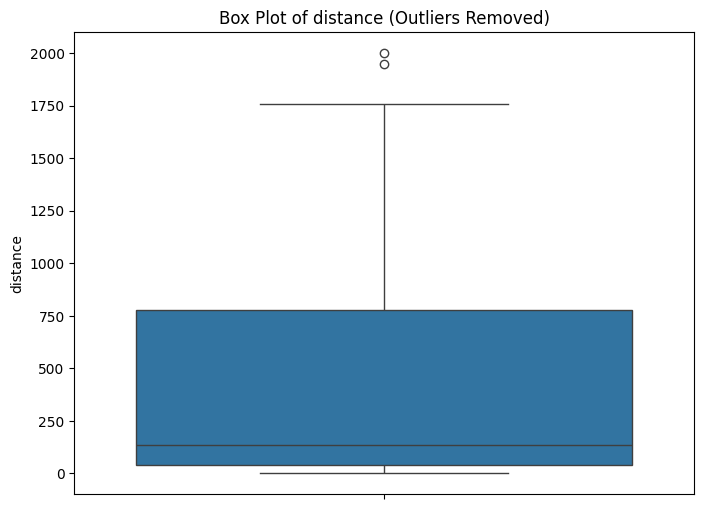

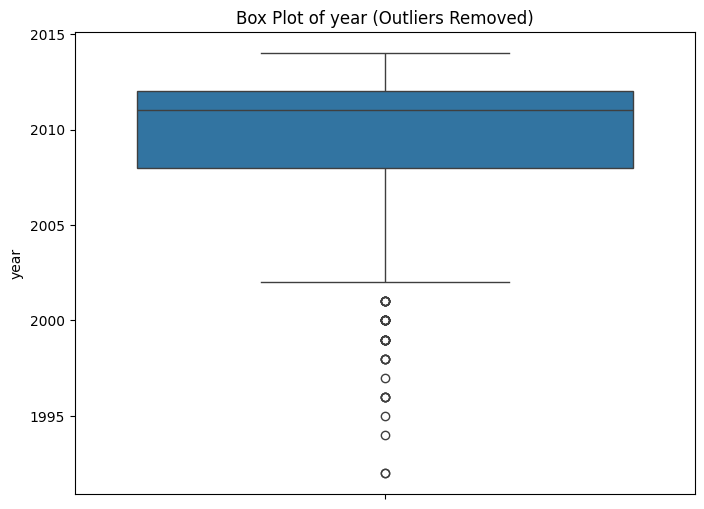

In [22]:
# prompt: in planets_copy, for column distance, delete outliers above 2000, for mass above 2.5, for orbital period above 50000

# Remove outliers based on specified conditions
planets_copy = planets_copy[planets_copy['distance'] <= 2000]
planets_copy = planets_copy[planets_copy['mass'] <= 2.5]
planets_copy = planets_copy[planets_copy['orbital_period'] <= 50000]

print("Shape of planets_copy after outlier removal:", planets_copy.shape)

# Optionally, visualize the box plots again to see the effect of outlier removal
planets_numerical_cleaned = planets_copy.select_dtypes(include=np.number)

for col in planets_numerical_cleaned.columns:
    plt.figure(figsize=(8, 6))
    sns.boxplot(y=planets_numerical_cleaned[col])
    plt.title(f'Box Plot of {col} (Outliers Removed)')
    plt.ylabel(col)
    plt.show()

In [23]:
# prompt: create new df called as planets_df_normalized. Use MinMax Scaler to scale the numerical values
# join the categorical values after

from sklearn.preprocessing import MinMaxScaler

# Separate numerical and categorical columns
numerical_cols = planets_copy.select_dtypes(include=np.number).columns
categorical_cols = planets_copy.select_dtypes(exclude=np.number).columns

# Initialize the MinMaxScaler
scaler = MinMaxScaler()

# Apply MinMax scaling to numerical columns
planets_numerical_scaled = scaler.fit_transform(planets_copy[numerical_cols])

# Convert scaled numerical values back to a DataFrame
planets_numerical_scaled_df = pd.DataFrame(planets_numerical_scaled, columns=numerical_cols, index=planets_copy.index)

# Get the categorical columns from the cleaned dataframe
planets_categorical_df = planets_copy[categorical_cols]

# Join the scaled numerical dataframe with the categorical dataframe
planets_df_normalized = pd.concat([planets_numerical_scaled_df, planets_categorical_df], axis=1)

print(planets_df_normalized.head())
print(planets_df_normalized.describe())

      number  orbital_period      mass  distance      year           method
1   0.000000        0.021867  0.883833  0.027819  0.727273  Radial Velocity
7   0.000000        0.019960  0.719596  0.010037  0.181818  Radial Velocity
9   0.166667        0.011318  0.795706  0.036745  0.818182  Radial Velocity
10  0.166667        0.022073  0.343054  0.036745  0.818182  Radial Velocity
14  0.333333        0.059773  0.214869  0.006369  0.409091  Radial Velocity
           number  orbital_period        mass    distance        year
count  857.000000      857.000000  857.000000  857.000000  857.000000
mean     0.146441        0.014429    0.550880    0.171905    0.794579
std      0.218065        0.064126    0.277234    0.187039    0.171150
min      0.000000        0.000000    0.000000    0.000000    0.000000
25%      0.000000        0.000113    0.343054    0.018347    0.727273
50%      0.000000        0.000567    0.719596    0.066870    0.863636
75%      0.166667        0.006923    0.719596    0.389

In [24]:
planets = sns.load_dataset('planets')
planets.shape

(1035, 6)

In [25]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [26]:
planets = sns.load_dataset('planets')
planets.shape

(1035, 6)